### Run the cell below to install split-folders

In [1]:
# !pip -qq install split-folders tqdm

### Run the cell below if you have a device that supports CUDA (change the CUDA version for your version of NVIDIA driver)

In [2]:
# !pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126

### Libraries imports

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
import random
import shutil
import splitfolders
from PIL import Image

In [ ]:
#Location of unorganized AID dataset
input_folder = "AID_complete"

#Parameters
num_classes = 30
num_epochs = 10
batch_size = 32

feature_extract = True

#Load the model if you have a trained one
load_model = True
best_model_path = 'best_model_50.pt'

# All the classes of the AID dataset
classes = ['Airport', 'BareLand', 'BaseballField', 'Beach', 'Bridge',
           'Center', 'Church', 'Commercial', 'DenseResidential', 'Desert',
           'Farmland', 'Forest', 'Industrial', 'Meadow', 'MediumResidential',
           'Mountain', 'Park', 'Parking', 'Playground', 'Pond', 'Port',
           'RailwayStation', 'Resort', 'River', 'School', 'SparseResidential',
           'Square', 'Stadium', 'StorageTanks', 'Viaduct']

### Run this once to split data into training and validation directories

In [5]:
# output_folder = "AID_split"
# splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.7, .3), group_prefix=None)

### Randomization seed

In [6]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True

### Data augmentation

In [7]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

### Data split

In [8]:
data = "AID_split"

image_datasets = {x: datasets.ImageFolder(os.path.join(data, x), data_transforms[x]) for x in ['train', 'val']}

dataloaders_dict = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size, shuffle=True, num_workers=4) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda:0


### Image example

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


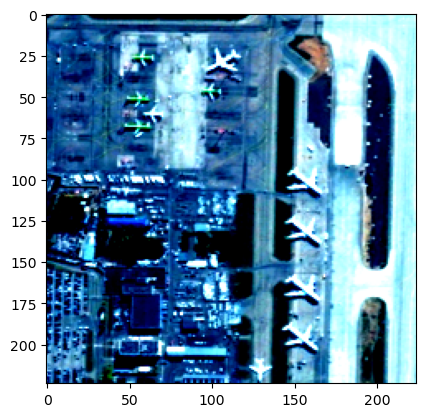

0 Airport


In [9]:
image,label = image_datasets['train'][15]
plt.imshow(image.permute(2,1,0))
plt.show()
print(label, image_datasets['train'].classes[label])

### Data Visualization

In [10]:
labels = image_datasets['train'].targets
_,labels_count = np.unique(labels, return_counts=True)
labels_count

array([251, 217, 154, 280, 251, 182, 168, 244, 287, 210, 259, 175, 273,
       196, 203, 237, 244, 273, 259, 294, 266, 182, 203, 287, 210, 210,
       230, 203, 251, 294], dtype=int64)

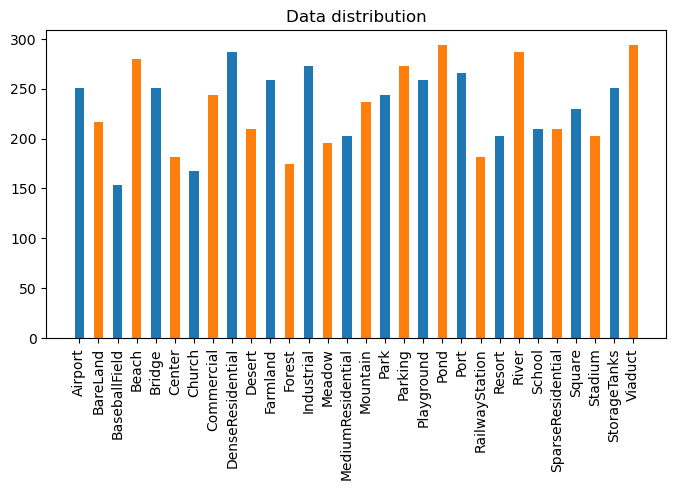

In [11]:
class_names = image_datasets['train'].classes

plt.figure(figsize=(8, 4))
plt.title('Data distribution')
plt.bar(class_names, labels_count, width=.5, color = ['C0', 'C1'])
plt.xticks(rotation='vertical')
plt.show()

### Model initialization

In [12]:
def set_parameter_requires_grad(model, feature_extracting):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False
            
def initialize_model(num_classes, feature_extract, use_pretrained=True):
    model = None
    
    # Can change the resnet model, the number corresponds to the number of layers (ResNet50 is the best performing so far)
    model = models.resnet50(pretrained=use_pretrained)
    set_parameter_requires_grad(model, feature_extract)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    
    return model

In [13]:
model = initialize_model(num_classes, feature_extract)

model = model.to(device)

c:\Users\diceb\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\diceb\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [14]:
params_to_update = model.parameters()
if feature_extract == True:
    params_to_update = []
    for name,param in model.named_parameters():
        if param.requires_grad == True:
            params_to_update.append(param)
else:
    for name,param in model.named_parameters():
        if param.requires_grad == True:
            print(name)
     
# Model optimizer            
optimizer = optim.Adam(params_to_update, lr = 0.0015)

### Model training

In [15]:
# Loss function
criterion = nn.CrossEntropyLoss()

In [16]:
def train_model(model, dataloaders, optimizer, criterion = criterion, num_epochs = num_epochs, is_inception = False):
    start = time.time()
    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
    
    best_model_weights = copy.deepcopy(model.state_dict())
    best_acc = 0
    
    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch + 1, num_epochs))
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()
                
            running_loss = 0
            running_corrects = 0
            
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    
                _, preds = torch.max(outputs, 1)
                
                if phase == 'train':
                    loss.backward()
                    optimizer.step()
                    
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)
            
            print('{} loss: {:.4f} acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            history[phase + '_acc'].append(epoch_acc.item())
            history[phase + '_loss'].append(epoch_loss)
            
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_weights = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), 'best_model_50.pt')
        print('\n')
                
    finish = time.time()
    elapsed_time = finish - start
    
    print('Training complete in {:.0f}m {:.0f}s'.format(elapsed_time // 60, elapsed_time % 60))
    print('Best val Acc: {:4f}'.format(best_acc))
    
    model.load_state_dict(best_model_weights)
    return model, history

In [17]:
if not load_model:      #do not train model if model is already trained and saved
    model, history = train_model(model, dataloaders_dict, optimizer, criterion, num_epochs, False)

Epoch 1/10
train loss: 1.3546 acc: 0.6323
val loss: 0.6885 acc: 0.8005


Epoch 2/10
train loss: 0.7148 acc: 0.7872
val loss: 0.6050 acc: 0.8078


Epoch 3/10
train loss: 0.6122 acc: 0.8157
val loss: 0.5189 acc: 0.8430


Epoch 4/10
train loss: 0.5672 acc: 0.8254
val loss: 0.6313 acc: 0.8128


Epoch 5/10
train loss: 0.5362 acc: 0.8354
val loss: 0.5379 acc: 0.8380


Epoch 6/10
train loss: 0.5455 acc: 0.8297
val loss: 0.4969 acc: 0.8533


Epoch 7/10
train loss: 0.5268 acc: 0.8357
val loss: 0.6525 acc: 0.8108


Epoch 8/10
train loss: 0.4939 acc: 0.8410
val loss: 0.5659 acc: 0.8390


Epoch 9/10
train loss: 0.4830 acc: 0.8547
val loss: 0.4591 acc: 0.8617


Epoch 10/10
train loss: 0.4980 acc: 0.8473
val loss: 0.5231 acc: 0.8447


Training complete in 13m 35s
Best val Acc: 0.861656


### Visualize the history of accruacy and loss while training

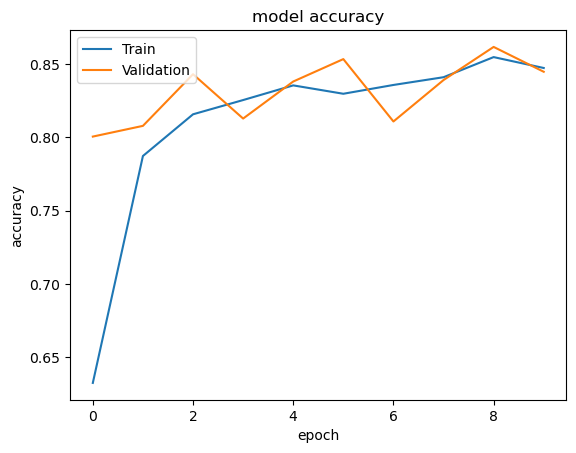

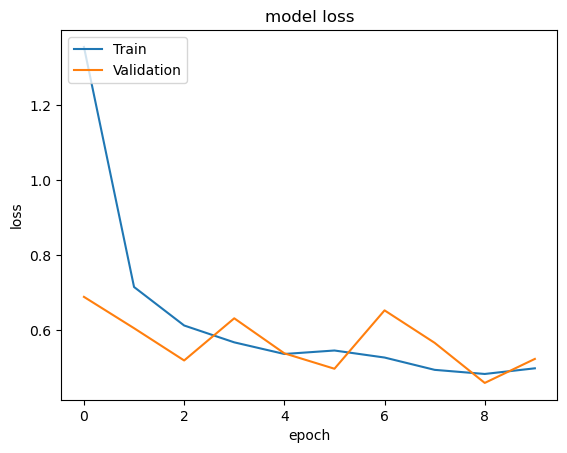

In [18]:
if not load_model:      #can't show history if model is already trained
    # summarize history for accuracy
    plt.plot(history['train_acc'])
    plt.plot(history['val_acc'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.savefig('ResNet50_acc.png')
    plt.show()
    # summarize history for loss
    plt.plot(history['train_loss'])
    plt.plot(history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.savefig('ResNet50_loss.png')
    plt.show()

### Load the best performing model

In [19]:
best_model = initialize_model(num_classes, feature_extract)
# In case the original model was trained on a GPU
if device.type != 'cpu':
    best_model.load_state_dict(torch.load(best_model_path))
else:
    best_model.load_state_dict(torch.load(best_model_path, map_location=torch.device('cpu')))
best_model = best_model.to(device)

### Temperature scaling

Temperature is a scalar parameter that determines the confidence of the model

Temperature < 1: make the model more confident

Temperature = 1: use the model's learned distribution

Temperature > 1: make the model less confident

In [20]:
# Model wrapper
class ModelWithTemprerature(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.temprerature = nn.Parameter(torch.tensor(1.0))

    def forward(self, x):
        logits = self.model(x)
        return self.temperature_scale(logits)
    
    # Scale logits by temperature
    def temperature_scale(self, logits):
        return logits / self.temprerature    

Collect pre-softmax outputs

In [21]:
# Collect logits on validation set
def collect_logits_labels(model, val_loader=dataloaders_dict['val'], device=device):
    model.eval()
    logits_list = []
    labels_list = []
    
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            logits_list.append(logits)
            
            labels_list.append(y)
            
    return torch.cat(logits_list), torch.cat(labels_list)

Optimize temperature for best results using quasi-Newton method
LBFGS is a optimization algorithm in the quasi-Newton family  
that approximates the inverse Hessian matrix using only a few vectors from previous iterations

In [22]:
# temprerature optimization
def set_temperature(model, logits, labels, device=device):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.LBFGS([model.temprerature], lr=0.01, max_iter=50)
    
    def eval():
        optimizer.zero_grad()
        loss = criterion(model.temperature_scale(logits), labels)
        loss.backward()
        return loss
    
    optimizer.step(eval)
    
    return model

#### First we try to learn the temperature using the validation data

In [23]:
best_model = ModelWithTemprerature(best_model).to(device)

logits, labels = collect_logits_labels(best_model)

best_model = set_temperature(best_model, logits, labels)

print(f"Temperature: {best_model.temprerature.item()}")

Temperature: 1.0545601844787598


#### We can also set the temperature manually

In [24]:
def manually_set_temperature(model, temperature):
    model_with_temperature = ModelWithTemprerature(model).to(device)
    model_with_temperature.temprerature = nn.Parameter(torch.tensor(temperature))
    return model_with_temperature

In [25]:
# Temperature < 1: make the model more confident
# Temperature = 1: use the model's learned distribution
# Temperature > 1: make the model less confident

# best_model = manually_set_temperature(best_model, 0.5)

Abstain option allows the model to skip the prediction on some data points  
that have lower than treshold highest probability

In [26]:
class ModelWithAbstainOption(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.abstain_threshold = nn.Parameter(torch.tensor(0.6))
        
    def forward(self, x):
        return self.model(x)
    
    def predict_with_abstain(self, x):
        logits = self.forward(x)
        probs = torch.nn.functional.softmax(logits, dim=1)
        max_probs, preds = torch.max(probs, dim=1)
        
        # Return predictions and abstain mask
        abstain_mask = max_probs < self.abstain_threshold   # Marks predictions if their probabilities are less than the threshold
        return preds, abstain_mask, max_probs

In [27]:
best_model = ModelWithAbstainOption(best_model).to(device)

In [28]:
def validate(model, val_loader=dataloaders_dict['val'], abstain=False, abstain_threshold=0.6, device=device):
    model.eval()
    model.abstain_threshold = nn.Parameter(torch.tensor(abstain_threshold))
    correct = 0
    total = val_loader.dataset.__len__()
    abstain_count = 0
    
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)
            
            if abstain:
                preds, abstain_mask, _ = model.predict_with_abstain(x)
                # Only count non-abstained predictions for accuracy
                non_abstain_mask = ~abstain_mask
                correct += (preds[non_abstain_mask] == y[non_abstain_mask]).sum().item()
                abstain_count += abstain_mask.sum().item()
            else:
                outputs = model(x)
                preds = torch.argmax(outputs, 1)
                correct += (preds == y).sum().item()
    
    if abstain:
        non_abstained = total - abstain_count
        accuracy = correct / non_abstained
        print(f'Abstain threshold: {abstain_threshold}')
        print(f'Accuracy on non-abstained predictions: {100 * accuracy:.2f}%')
        print(f'Abstained: {abstain_count}/{total} ({100 * abstain_count / total:.2f}%)')
    else:
        accuracy = correct / total
        print(f'Accuracy of the network on the validation images: {100 * accuracy:.2f}%')
            
    return accuracy

In [29]:
# Test validation without abstain
validate(best_model)

# Test validation with abstain
validate(best_model, abstain=True)

Accuracy of the network on the validation images: 86.17%
Abstain threshold: 0.6
Accuracy on non-abstained predictions: 92.38%
Abstained: 383/3007 (12.74%)


0.9237804878048781

### Function to test the model

In [30]:
def predict_image(image_path, model, transform = data_transforms['val'], show_image = True, abstain = False, abstain_threshold = 0.6, device=device):
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    model.abstain_threshold = nn.Parameter(torch.tensor(abstain_threshold))
    
    if show_image:
        plt.figure(figsize=(5, 3))
        plt.axis('off')
        plt.imshow(image)
    
    with torch.no_grad():
        model.eval()
        output = model(input_tensor)
        probs = torch.nn.functional.softmax(output[0], dim=0)
        if abstain:
            pred, abstain_mask, _ = model.predict_with_abstain(input_tensor)
            pred = pred.item()
            pred_class = classes[pred]
            return pred_class, pred, probs[pred].item(), abstain_mask.item()
        else:
            pred = torch.argmax(probs).item()
            pred_class = classes[pred]
            return pred_class, pred, probs[pred].item()
    

### Manual tests

('Airport', 0, 0.9998458623886108, False)

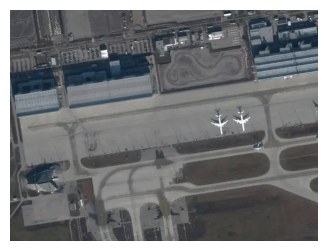

In [31]:
image_path = 'tests/1.png'
predict_image(image_path, best_model, abstain=True)

('Commercial', 7, 0.9587169885635376, False)

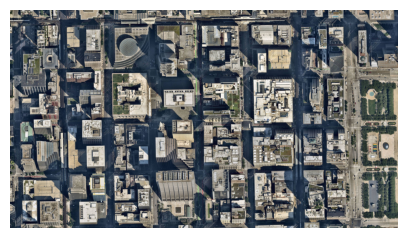

In [32]:
image_path = 'tests/2.png'
predict_image(image_path, best_model, abstain=True)

('Mountain', 15, 0.9585962891578674, False)

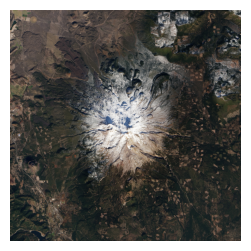

In [33]:
image_path = 'tests/3.png'
predict_image(image_path, best_model, abstain=True)

('Viaduct', 29, 0.7356569170951843, False)

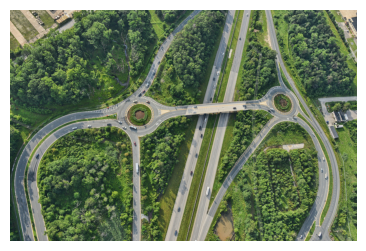

In [34]:
image_path = 'tests/4.png'
predict_image(image_path, best_model, abstain=True)

('Park', 16, 0.7679409384727478, False)

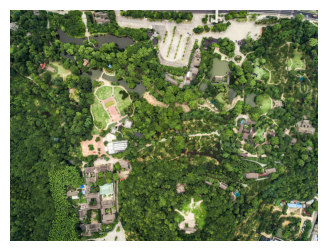

In [35]:
image_path = 'tests/5.png'
predict_image(image_path, best_model, abstain=True)

('Resort', 22, 0.34042319655418396, True)

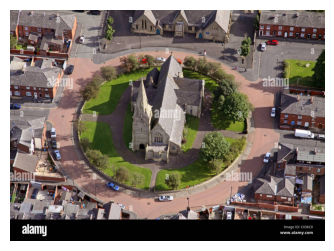

In [36]:
image_path = 'tests/13.png'
predict_image(image_path, best_model, abstain=True)